<a href="https://colab.research.google.com/github/satin-vasita/DSPY-Practicals-Colab-Notebooks/blob/main/Miniproject2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# NOTEBOOK 2: Exploratory Data Analysis (Graphical + Non-Graphical)

# CELL 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [ ]:
# CELL 2 — Load Data
df = pd.read_csv('cleaned_airline_data.csv')
print(df.shape)
df.head()

(49281, 14)


,num_passengers,sales_channel,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,trip_type_CircleTrip,trip_type_OneWay,trip_type_RoundTrip
0,2,0,256,19.0,7,5,1,0,0,5.52,0,False,False,True
1,1,0,112,20.0,3,5,0,0,0,5.52,0,False,False,True
2,2,0,243,22.0,17,2,1,1,0,5.52,0,False,False,True
3,1,0,96,31.0,4,5,0,0,1,5.52,0,False,False,True
4,2,0,68,22.0,15,2,1,0,1,5.52,0,False,False,True


In [ ]:
# ──────────────────────────────────────────────
# NON-GRAPHICAL EDA 1 — Univariate
# ──────────────────────────────────────────────

# CELL 3
"""
Information Sought : Understand central tendency and spread of numerical features.
Type of EDA        : Non-Graphical | Univariate
Observation        : purchase_lead has high std (~100 days) — bookings range from
                     last-minute to months in advance. length_of_stay is right-skewed.
                     Most bookings are for 1–2 passengers.
Concluding Remark  : High variance in purchase_lead and length_of_stay confirms
                     outlier capping in NB1 was necessary. These will be key ML features.
"""
stats = df.describe().T
stats['skewness'] = df.select_dtypes(include=np.number).skew()
print(stats)


                         count       mean        std   min    25%    50%  \
num_passengers         49281.0   1.590187   1.016538  1.00   1.00   1.00   
sales_channel          49281.0   0.108845   0.311448  0.00   0.00   0.00   
purchase_lead          49281.0  79.774233  76.806868  0.00  21.00  51.00   
length_of_stay         49281.0  19.371624  18.317244  0.00   5.00  17.00   
flight_hour            49281.0   9.070676   5.413099  0.00   5.00   9.00   
flight_day             49281.0   2.813620   1.991913  0.00   1.00   3.00   
wants_extra_baggage    49281.0   0.668229   0.470854  0.00   0.00   1.00   
wants_preferred_seat   49281.0   0.295631   0.456331  0.00   0.00   0.00   
wants_in_flight_meals  49281.0   0.426635   0.494593  0.00   0.00   0.00   
flight_duration        49281.0   7.279974   1.496390  4.67   5.62   7.57   
booking_complete       49281.0   0.149977   0.357052  0.00   0.00   0.00   

                          75%    max  skewness  
num_passengers           2.00    9.0  

In [ ]:
# CELL 4
"""
Information Sought : Which features are most correlated with booking_complete?
Type of EDA        : Non-Graphical | Multivariate (Correlation)
Observation        : wants_extra_baggage, wants_preferred_seat, wants_in_flight_meals
                     are positively correlated with the target. purchase_lead is
                     weakly negative (last-minute bookers tend to complete more).
Concluding Remark  : Add-on selections are the strongest linear predictors of
                     booking completion and should be prioritized in the ML model.
"""
corr = df.corr()
print(corr['booking_complete'].sort_values(ascending=False))

booking_complete         1.000000
wants_extra_baggage      0.068452
wants_preferred_seat     0.050189
trip_type_RoundTrip      0.028462
wants_in_flight_meals    0.026399
num_passengers           0.024092
flight_hour              0.006705
flight_day              -0.007061
trip_type_CircleTrip    -0.014539
trip_type_OneWay        -0.024428
purchase_lead           -0.024533
sales_channel           -0.039320
length_of_stay          -0.072377
flight_duration         -0.106529
Name: booking_complete, dtype: float64


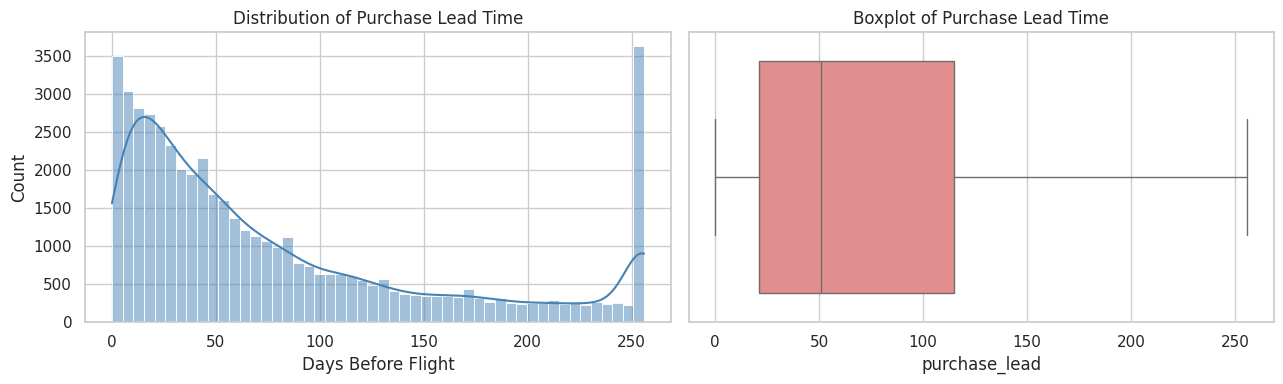

In [ ]:
"""
Information Sought : How is purchase_lead distributed? Are there distinct booking patterns?
Type of EDA        : Graphical | Univariate (Histogram + KDE)
Observation        : Right-skewed. Large spike near 0–30 days (last-minute).
                     Long tail up to ~300 days for early planners.
Concluding Remark  : Two types of bookers exist — last-minute and planners.
                     This bimodal behaviour makes purchase_lead a strong ML feature.
"""
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['purchase_lead'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Purchase Lead Time')
axes[0].set_xlabel('Days Before Flight')

sns.boxplot(x=df['purchase_lead'], color='lightcoral', ax=axes[1])
axes[1].set_title('Boxplot of Purchase Lead Time')

plt.tight_layout()
plt.show()

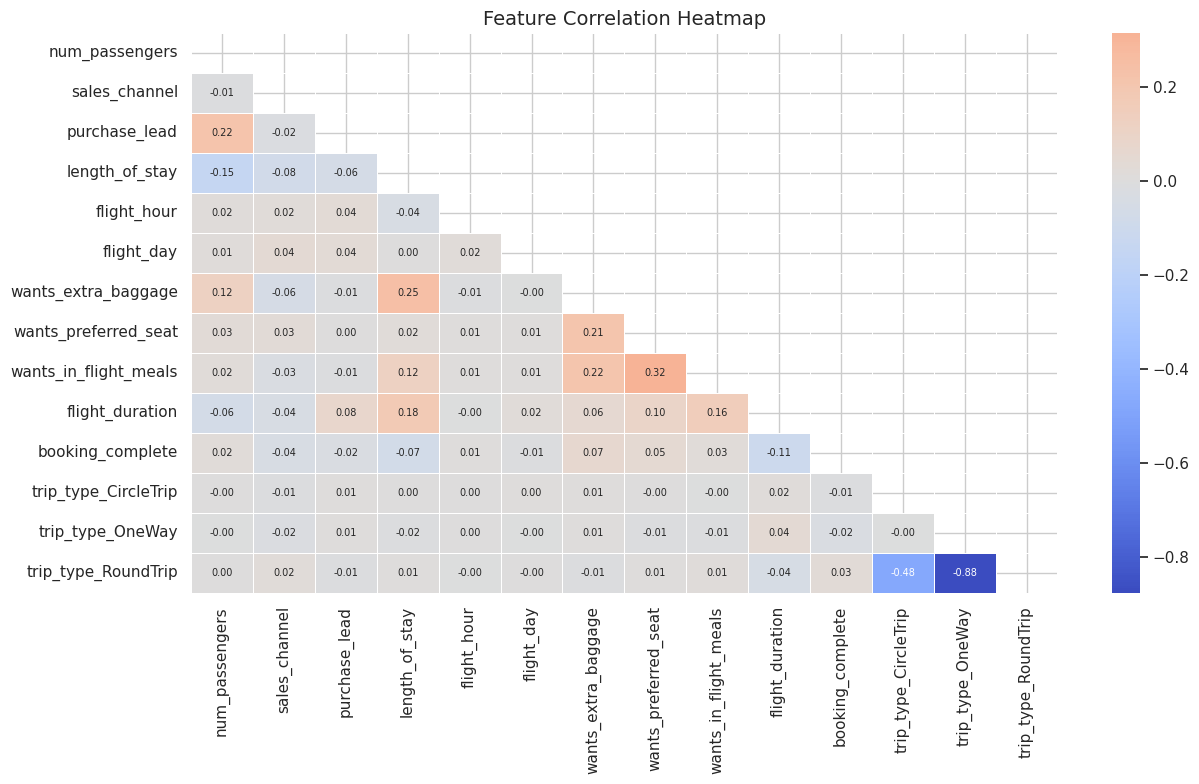

In [ ]:
# CELL 6
"""
Information Sought : Which features correlate strongly with each other and with the target?
Type of EDA        : Graphical | Multivariate (Heatmap)
Observation        : The three add-on features (baggage, seat, meals) are moderately
                     correlated with each other and positively with booking_complete.
                     purchase_lead shows a slight negative correlation with the target.
Concluding Remark  : Mild multicollinearity between add-ons is acceptable. All three
                     should be retained as they collectively signal booking intent.
"""
plt.figure(figsize=(13, 8))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# CELL 7 — BONUS: Interactive Plotly (Multivariate)
fig = px.scatter(
    df.sample(3000, random_state=42),
    x='purchase_lead', y='flight_duration',
    color=df.sample(3000, random_state=42)['booking_complete'].map({0:'Not Completed', 1:'Completed'}),
    title='Purchase Lead vs Flight Duration by Booking Completion',
    opacity=0.5,
    color_discrete_map={'Not Completed': '#FF6B6B', 'Completed': '#4ECDC4'}
)
fig.show()

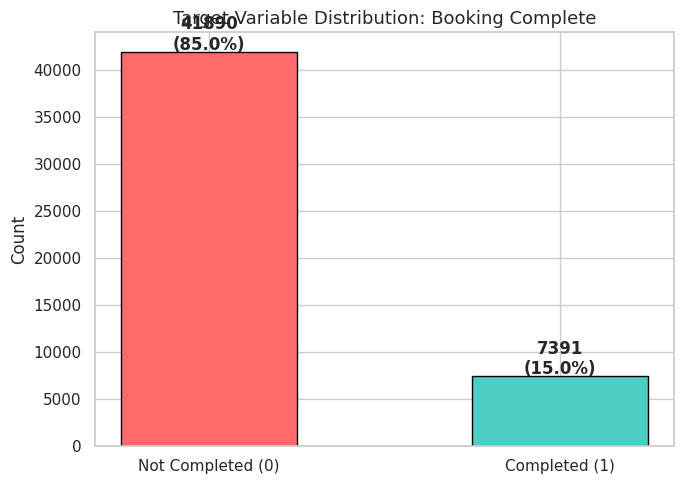

In [ ]:
# CELL 8
"""
Information Sought : What is the distribution of the target variable booking_complete?
                     Is the dataset balanced or imbalanced?
Type of EDA        : Graphical | Univariate (Bar Chart)
Observation        : The majority of bookings are NOT completed (class 0).
                     Only ~15% of bookings are completed — heavily imbalanced.
Concluding Remark  : Class imbalance must be handled before ML modeling (via SMOTE
                     in NB3). A naive model would just predict 0 and still get ~85% accuracy.
"""
counts = df['booking_complete'].value_counts()
labels = ['Not Completed (0)', 'Completed (1)']
colors = ['#FF6B6B', '#4ECDC4']

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
plt.title('Target Variable Distribution: Booking Complete', fontsize=13)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

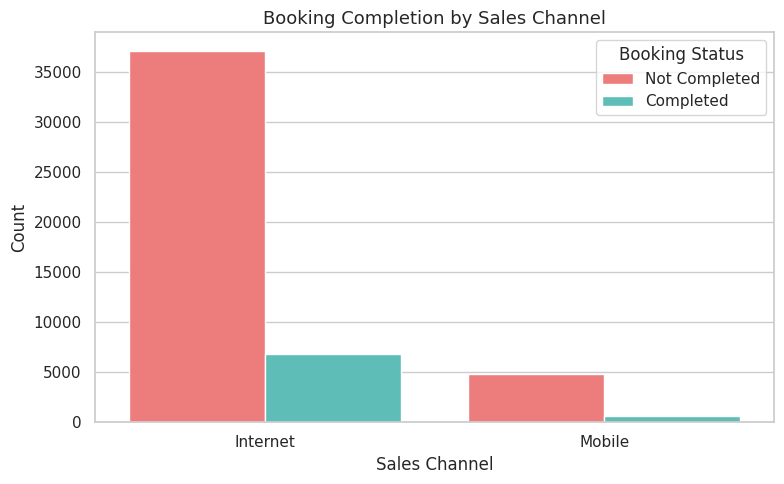

In [ ]:
"""
Information Sought : Do customers using different sales channels complete bookings
                     at different rates?
Type of EDA        : Graphical | Multivariate (Grouped Bar Chart)
Observation        : Internet bookings dominate in both completed and not-completed
                     categories. However, Internet users show a relatively higher
                     completion rate compared to Mobile users.
Concluding Remark  : Sales channel influences booking completion. Internet users
                     are more likely to finish the booking process, possibly due to
                     a better UI/UX experience on desktop.
"""
channel_map = {0: 'Internet', 1: 'Mobile'}
df['channel_label'] = df['sales_channel'].map(channel_map)
channel_grp = df.groupby(['channel_label', 'booking_complete']).size().reset_index(name='count')
channel_grp['status'] = channel_grp['booking_complete'].map({0: 'Not Completed', 1: 'Completed'})

plt.figure(figsize=(8, 5))
sns.barplot(data=channel_grp, x='channel_label', y='count', hue='status',
            palette={'Not Completed': '#FF6B6B', 'Completed': '#4ECDC4'})
plt.title('Booking Completion by Sales Channel', fontsize=13)
plt.xlabel('Sales Channel')
plt.ylabel('Count')
plt.legend(title='Booking Status')
plt.tight_layout()
plt.show()

df.drop(columns=['channel_label'], inplace=True)  # cleanup temp column

<Axes: xlabel='booking_complete', ylabel='flight_duration'>

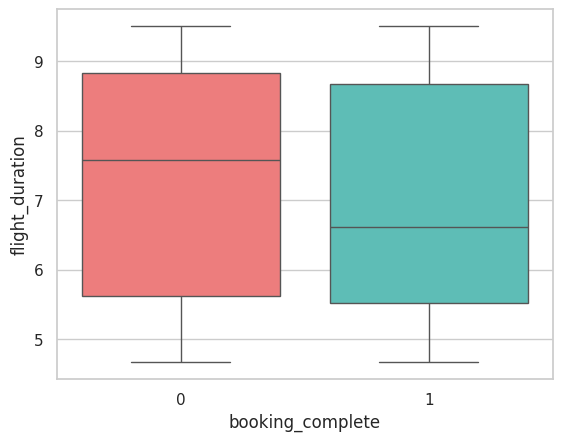

In [ ]:
"""
Information Sought : Does flight duration differ between customers who completed
                     their booking vs those who didn't?
Type of EDA        : Graphical | Multivariate (Boxplot)
Observation        : Customers who completed their booking tend to have slightly
                     longer flight durations. The median flight duration is higher
                     for completed bookings.
Concluding Remark  : Longer flights may indicate more planned/committed trips,
                     which correlates with higher booking completion. flight_duration
                     is a useful feature for the ML model.
"""
sns.boxplot(
    data=df,
    x='booking_complete',
    y='flight_duration',
    palette={'0': '#FF6B6B', '1': '#4ECDC4'}
)